In [25]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

In [21]:
data = np.load('../solutions/formationchannels.npy')

Text(0.5, 1.0, 'bins = 100')

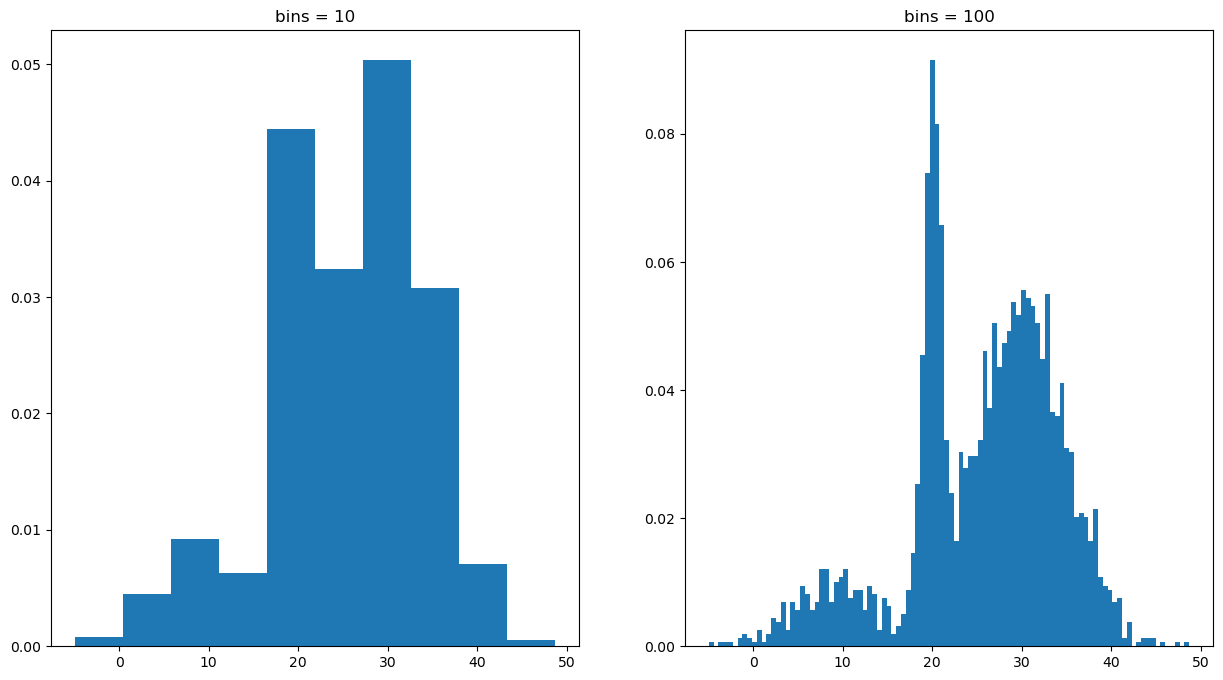

In [46]:
fig = plt.figure(figsize=(15, 8))
#fig.subplots_adjust(left=0.11, right=0.95, bottom=0.2, top=0.9, wspace=0.25)

ax=fig.add_subplot(121)
_ = ax.hist(data, bins = 10, density = True)
ax.set_title(f'bins = {10}')

ax=fig.add_subplot(122)
_ = ax.hist(data, bins = 100, density = True)
ax.set_title(f'bins = {100}')

In [23]:
print(data)
print(np.shape(data))

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]
(2950, 1)


In [35]:
aic = []
for i in np.arange(1,11,1):
    gm = GaussianMixture(n_components=i).fit(data)
    aic.append(gm.aic(data))

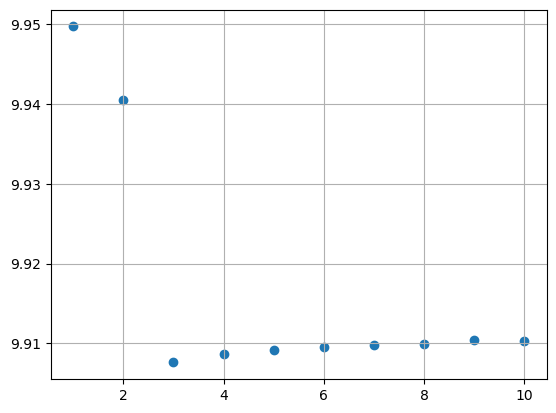

In [40]:
plt.scatter(np.arange(1,11,1), np.log(aic))
plt.grid(True)

In [76]:
gm_max = GaussianMixture(n_components=(np.argmin(aic)+1)).fit(data) # fitted mixture

In [77]:
gaussmix, _ = gm_max.sample(1000)

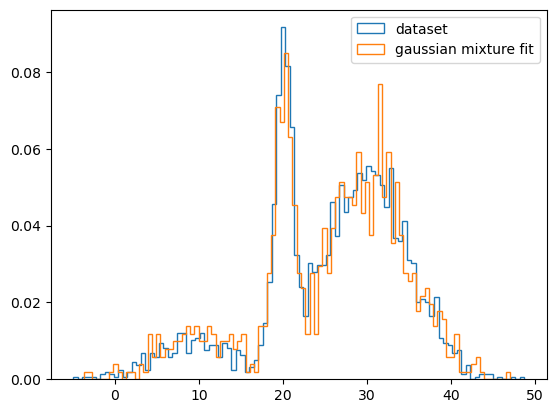

In [78]:
_ = plt.hist(data, bins = 100, histtype = 'step', density = True, label = 'dataset')
_ = plt.hist(gaussmix, bins = 100, density = True, histtype = 'step', label = 'gaussian mixture fit')
plt.legend()

In [ ]:
scores = gm_max.score_samples(data)
probes = gm_max.predict_proba(data) # why is this useful?

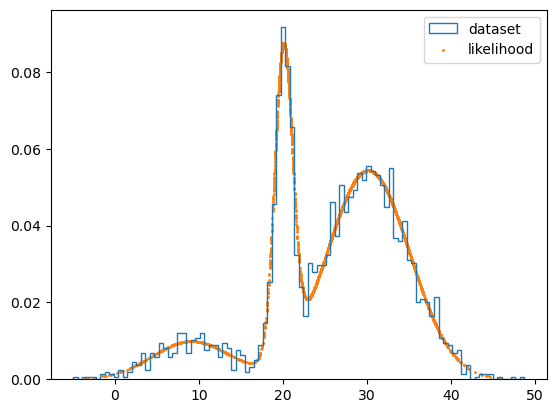

In [75]:
_ = plt.hist(data, bins = 100, histtype = 'step', density = True, label = 'dataset')
plt.scatter(data, np.exp(scores), s = 1., label = 'likelihood')
plt.legend()